<a href="https://colab.research.google.com/github/LucyAlex12/-Arinze-Chioma-Lucy/blob/main/Assignment_Three_AI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Diabetes Prediction using Logistic Regression

In [41]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (4).csv


Load the diabetes dataset into a pandas DataFrame

In [42]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Clean the data by replacing invalid zero values with median values

In [43]:
import numpy as np

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Fill with median
df.fillna(df.median(), inplace=True)

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Split the dataset into training (80%) and testing (20%) sets

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train a Logistic Regression model using the training data

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Use the trained model to make predictions on the test data

In [46]:
y_pred = model.predict(X_test)

Evaluate the model using accuracy, precision, recall, and F1-score

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641


Generate a confusion matrix to analyze prediction performance

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[82 17]
 [21 34]]


Display the classification report for detailed performance metrics

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



The screenshot below shows the classification report as required in the assignment.

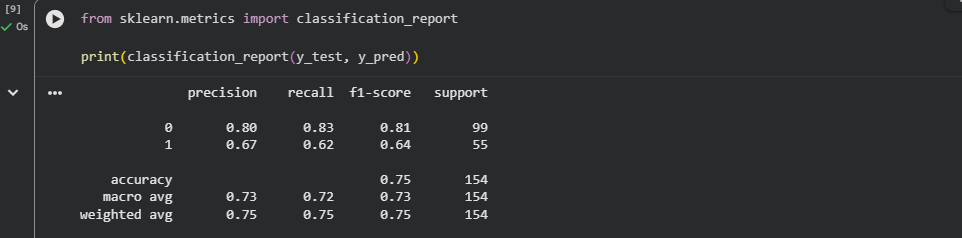

Predict diabetes outcome for a new patient using given values

In [50]:
insulin_median = df['Insulin'].median()

new_patient = pd.DataFrame([{
    'Pregnancies': 0,
    'Glucose': 148,
    'BloodPressure': 72,
    'SkinThickness': df['SkinThickness'].median(),
    'Insulin': insulin_median,
    'BMI': 33.6,
    'DiabetesPedigreeFunction': df['DiabetesPedigreeFunction'].median(),
    'Age': 50
}])

prediction = model.predict(new_patient)

print("Prediction:", prediction[0])

Prediction: 1


**Final Interpretation**

The model predicted that the patient is diabetic (1).

This prediction is influenced by key factors such as a high glucose level (148), elevated BMI (33.6), and age (50), which are strong indicators of diabetes risk.

The model shows reasonable performance and can be used as a basic tool for diabetes prediction.